## EVTOL & Passenger arrival time distribution

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import folium
import math

# eVTOL Stochastic Scheduling - Global Configuration

# Simulation Settings
BASE_PRICE = 0.1482   # Average residential electricity rate in Dallas (PowerChoiceTexas.org, 2025)
M_PEAK = 1.5          # CoServ TOU Rate Sheet: Peak ≈ 20.92¢/kWh
M_SHOULDER = 1.05     # Shoulder multiplier (transitional pricing)
M_OFF = 0.6           # CoServ TOU Rate Sheet: Off-peak ≈ 8.56¢/kWh
# Reference: https://www.powerchoicetexas.org/cities/dallas-electricity-rates , https://www.coserv.com/service/residential/residential-rates/

# eVTOL and Battery Parameters
SOC_MIN = 70.0                      # Minimum required state of charge (%)
BATTERY_CAPACITY = 150.0            # Battery capacity in kWh
CHARGING_RATE = 125                 # Charging power in kW
EVTOL_CAPACITY = 4                  # Maximum passengers per eVTOL
# Reference: Z. Wu, Y. Zhang, Optimal eVTOL charging and passenger scheduling, AIAA Aviation 2020 Forum, 2020.

# Scenario Generation Parameters
N_SCENARIOS = 30                    # Number of demand scenarios generated
TARGET_SCENARIOS = 3                # Number of reduced representative scenarios
#HORIZON_MINUTES = 240               # 4-hour simulation horizon (240 minutes total)
HORIZON_START = 360   # 6AM
HORIZON_END = 1080    # 6PM
HORIZON_MINUTES = 720               # 12-hour simulation horizon (720 minutes)
BIN_SIZE = 10                       # Each time bin equals 10 minutes
L_PERIODS = HORIZON_MINUTES // BIN_SIZE   # 72 periods (12h × 60 / 10)

# Model Parameters
M_FACILITIES = 3                    # Number of charging facilities
LOS = 2                             # Level of Service: maximum waiting time (2 periods = 20 min)

# Randomization Control
SEED = 60                           # Random seed for reproducibility

# Vertiport Network Definition (Hub + 9 Destinations)
vertiports = {
    'Dallas CBD': (32.7767, -96.7970),
    'DFW Airport': (32.8998, -97.0409),
    'Dallas Love Field Airport': (32.84815, -96.85135),
    'Fort Worth City Center': (32.75550, -97.33080),
    'Mesquite Metro Airport': (32.7470, -96.5304),
    'Dallas Executive Airport (RBD)': (32.6810, -96.8690),
    'Denton Municipal Airport': (33.20083, -97.19778),
    'Fort Worth Meacham International Airport': (32.81969, -97.36319),
    'Arlington Municipal Airport': (32.6639, -97.0943),
    'McKinney National Airport': (33.1753, -96.5825)
}

# Haversine Function to Calculate Distance in Miles
def haversine_miles(lat1, lon1, lat2, lon2):
    """Compute great-circle distance between two coordinates in miles."""
    R = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def run_scenario(hub_name, assignment_case):
    """Run an eVTOL demand scenario for a given hub (Dallas CBD or DFW Airport)."""
    hub_coord = vertiports[hub_name]
    DESTINATION_DATA = {}

    # ============================================================
    # 1️⃣ Distance and Fare Setup
    # ============================================================
    for name, coord in vertiports.items():
        if name == hub_name:
            continue
        dist = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
        fare = round(20 + 3 * dist, 2)
        DESTINATION_DATA[name] = {'distance': dist, 'fare': fare}

    # ============================================================
    # 2️⃣ Assignment Logic (depends on hub)
    # ============================================================
    if assignment_case == 1:
        assignment = {'DFW Airport': 0.25, 'Fort Worth City Center': 0.20}
    elif assignment_case == 2:
        assignment = {'Dallas CBD': 0.25, 'Fort Worth City Center': 0.20}
    else:
        raise ValueError("assignment_case must be 1 (Dallas CBD) or 2 (DFW Airport)")

    remaining = [k for k in DESTINATION_DATA.keys() if k not in assignment]
    leftover = max(0.0, 1.0 - sum(assignment.values()))
    for k in remaining:
        assignment[k] = leftover / len(remaining)

    # ============================================================
    # 3️⃣ Passenger & eVTOL Arrival Distributions (merged here)
    # ============================================================
    if assignment_case == 1:  # Dallas CBD (morning demand)
        passenger_arrivals = np.concatenate([
            np.random.normal(7.5 * 60, 40, 400),    # main morning peak (~7:30 AM)
            np.random.normal(12.0 * 60, 60, 180),   # light lunch traffic
            np.random.normal(16.0 * 60, 70, 160)    # minor afternoon wave (~4 PM)
        ])
        evtol_arrivals = np.concatenate([
            np.random.normal(7.0 * 60, 45, 220),
            np.random.normal(8.0 * 60, 40, 220),
            np.random.normal(12.5 * 60, 60, 120),
            np.random.normal(16.5 * 60, 70, 120)
        ])

    elif assignment_case == 2:  # DFW Airport (evening demand)
        passenger_arrivals = np.concatenate([
            np.random.normal(8.0 * 60, 50, 150),
            np.random.normal(13.0 * 60, 60, 160),
            np.random.normal(19.5 * 60, 40, 420)
        ])
        evtol_arrivals = np.concatenate([
            np.random.normal(7.5 * 60, 50, 160),
            np.random.normal(12.5 * 60, 55, 180),
            np.random.normal(19.0 * 60, 45, 400)
        ])

    # Clip to [6AM–6PM]
    passenger_arrivals = passenger_arrivals[
        (passenger_arrivals >= HORIZON_START) & (passenger_arrivals < HORIZON_END)
    ]
    evtol_arrivals = evtol_arrivals[
        (evtol_arrivals >= HORIZON_START) & (evtol_arrivals < HORIZON_END)
    ]

    # ============================================================
    # 4️⃣ Scenario Summary Output
    # ============================================================
    print(f"\n=== {hub_name} Scenario ===")
    print("Destination                    Dist(mi)   Fare($)   Share(%)")
    print("-------------------------------------------------------------")
    for name, data in DESTINATION_DATA.items():
        share = assignment[name] * 100
        print(f"{name:<30} {data['distance']:>8.1f} {data['fare']:>9.2f} {share:>9.1f}")

    # ============================================================
    # 5️⃣ Demand Visualization
    # ============================================================
    fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axs[0].hist(passenger_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
    axs[0].set_title(f"Passenger Arrivals — Case {assignment_case}")
    axs[0].set_ylabel("Count")

    axs[1].hist(evtol_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
    axs[1].set_title(f"eVTOL Arrivals — Case {assignment_case}")
    axs[1].set_xlabel("Time (min since midnight)")
    axs[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 6️⃣ Map Visualization
    # ============================================================
    m = folium.Map(location=hub_coord, zoom_start=9)
    for name, coord in vertiports.items():
        color = 'red' if name == hub_name else 'blue'
        folium.CircleMarker(location=coord, radius=8, popup=name,
                            color=color, fill=True, fill_color=color).add_to(m)
    for name, coord in vertiports.items():
        if name == hub_name:
            continue
        folium.PolyLine([hub_coord, coord], color='black',
                        tooltip=f"{name}: {DESTINATION_DATA[name]['distance']:.1f} mi | ${DESTINATION_DATA[name]['fare']:.0f}").add_to(m)

    # ============================================================
    # 7️⃣ Return Results
    # ============================================================
    return {
        "hub": hub_name,
        "assignment_case": assignment_case,
        "destinations": DESTINATION_DATA,
        "assignment_shares": assignment,
        "passenger_arrivals": passenger_arrivals,
        "evtol_arrivals": evtol_arrivals,
        "map": m
    }

result = run_scenario('Dallas CBD', 1)
m1 = result['map']



'''
# Define Hub and Calculate Destination Data
hub_name = 'Dallas CBD'
hub_coord = vertiports[hub_name]
NUM_DESTINATIONS = len(vertiports) - 1

DESTINATION_DATA = {}
for name, coord in vertiports.items():
    if name == hub_name:
        continue
    dist_miles = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
    fare = round(20 + 3 * dist_miles, 2)
    DESTINATION_DATA[name] = {"distance": dist_miles, "fare": fare}

# Destination Number and Fare Mapping
destination_map = {i + 1: name for i, name in enumerate(DESTINATION_DATA.keys())}
name_to_number = {name: i for i, name in destination_map.items()}
numbered_fares = {i + 1: DESTINATION_DATA[name]["fare"] for i, name in enumerate(DESTINATION_DATA.keys())}

# Destination Summary Table
print(f"\nNumber of destinations: {NUM_DESTINATIONS}\n")
print("Destination Summary (from Dallas CBD)")
print("No.   Destination                              Miles     Fare ($)")
print("---------------------------------------------------------------")
for num, name in destination_map.items():
    data = DESTINATION_DATA[name]
    print(f"{num:<5} {name:<40} {data['distance']:>8.1f} {data['fare']:>10.2f}")

# Map Visualization
m = folium.Map(location=hub_coord, zoom_start=9)
for name, coord in vertiports.items():
    color = 'red' if name == hub_name else 'blue'
    folium.CircleMarker(location=coord, radius=8, popup=name,
                        color=color, fill=True, fill_color=color).add_to(m)

for name, coord in vertiports.items():
    if name == hub_name:
        continue
    dist_miles = DESTINATION_DATA[name]["distance"]
    fare = DESTINATION_DATA[name]["fare"]
    folium.PolyLine([hub_coord, coord], color='black', weight=2, opacity=0.6,
                    tooltip=f"{name}: {dist_miles:.1f} mi | ${fare:.0f}").add_to(m)

m
'''


=== Dallas CBD Scenario ===
Destination                    Dist(mi)   Fare($)   Share(%)
-------------------------------------------------------------
DFW Airport                        16.5     69.55      25.0
Dallas Love Field Airport           5.9     37.58       7.9
Fort Worth City Center             31.0    113.15      20.0
Mesquite Metro Airport             15.6     66.88       7.9
Dallas Executive Airport (RBD)      7.8     43.48       7.9
Denton Municipal Airport           37.4    132.18       7.9
Fort Worth Meacham International Airport     33.0    119.05       7.9
Arlington Municipal Airport        19.0     76.87       7.9
McKinney National Airport          30.2    110.65       7.9

=== DFW Airport Scenario ===
Destination                    Dist(mi)   Fare($)   Share(%)
-------------------------------------------------------------
Dallas CBD                         16.5     69.55      25.0
Dallas Love Field Airport          11.6     54.69       7.9
Fort Worth City Center   

'\n# Define Hub and Calculate Destination Data\nhub_name = \'Dallas CBD\'\nhub_coord = vertiports[hub_name]\nNUM_DESTINATIONS = len(vertiports) - 1\n\nDESTINATION_DATA = {}\nfor name, coord in vertiports.items():\n    if name == hub_name:\n        continue\n    dist_miles = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])\n    fare = round(20 + 3 * dist_miles, 2)\n    DESTINATION_DATA[name] = {"distance": dist_miles, "fare": fare}\n\n# Destination Number and Fare Mapping\ndestination_map = {i + 1: name for i, name in enumerate(DESTINATION_DATA.keys())}\nname_to_number = {name: i for i, name in destination_map.items()}\nnumbered_fares = {i + 1: DESTINATION_DATA[name]["fare"] for i, name in enumerate(DESTINATION_DATA.keys())}\n\n# Destination Summary Table\nprint(f"\nNumber of destinations: {NUM_DESTINATIONS}\n")\nprint("Destination Summary (from Dallas CBD)")\nprint("No.   Destination                              Miles     Fare ($)")\nprint("------------------------------

In [ ]:
# ============================================================
# ⚡ Energy Price Function (1-hour version)
# ============================================================
def energy_price_per_kWh(t, base=BASE_PRICE, m_peak=M_PEAK,
                         m_shoulder=M_SHOULDER, m_off=M_OFF):
    """Time-of-Use (TOU) pricing function. t in [0,24). Returns $/kWh."""
    if not (0 <= t < 24):
        raise ValueError("t must be in [0,24)")
    if 16 <= t < 21:                      # 4–9 pm
        return base * m_peak
    elif 0 <= t < 6 or 21 <= t < 24:      # midnight–6 am, 9 pm–midnight
        return base * m_off
    else:                                 # shoulder
        return base * m_shoulder

# ============================================================
# 🚁 eVTOL & Passenger Simulation (6 AM–6 PM, Assignment-Aware)
# ============================================================
def simulate_evtol_and_passengers(seed=SEED,
                                  soc_min=SOC_MIN,
                                  battery_capacity=BATTERY_CAPACITY,
                                  charging_rate=CHARGING_RATE,
                                  destination_data=None,
                                  assignment_case=1,
                                  plot=True):
    """
    Simulate eVTOL & passenger arrivals for a 12-hour horizon (6 AM–6 PM).
    Uses assignment_case rules:
        1 → Dallas CBD hub
        2 → DFW Airport hub
    """
    np.random.seed(seed)
    random.seed(seed)


    # ---- 1) Passenger & eVTOL arrivals (hub-specific peaks) ----
    if assignment_case == 1:      # Case 1 → Dallas CBD hub (morning demand)
        # Passengers: heavy morning flow (6:30–8:30 AM) plus light midday & afternoon shoulder
        passenger_arrivals = np.concatenate([
            np.random.normal(7.5 * 60, 40, 400),    # main morning peak (~7:30 AM)
            np.random.normal(12.0 * 60, 60, 180),   # light lunch traffic
            np.random.normal(16.0 * 60, 70, 160)    # minor afternoon wave (~4 PM)
        ])

        # eVTOLs roughly aligned with passenger activity (slightly staggered)
        evtol_arrivals = np.concatenate([
            np.random.normal(7.0 * 60, 45, 220),    # pre-peak staging (~7 AM)
            np.random.normal(8.0 * 60, 40, 220),    # active peak (~8 AM)
            np.random.normal(12.5 * 60, 60, 120),   # lunch window
            np.random.normal(16.5 * 60, 70, 120)    # afternoon operations
        ])

    elif assignment_case == 2:    # Case 2 → DFW Airport hub (evening demand)
        # Passengers: heavy evening flow (6:30–8:30 PM) plus light AM & midday
        passenger_arrivals = np.concatenate([
            np.random.normal(8.0 * 60, 50, 150),    # early departures (~8 AM)
            np.random.normal(13.0 * 60, 60, 160),   # midday transfer
            np.random.normal(19.5 * 60, 40, 420)    # main evening peak (~7:30 PM)
        ])

        # eVTOLs aligned with passenger demand (airport-bound evening)
        evtol_arrivals = np.concatenate([
            np.random.normal(7.5 * 60, 50, 160),    # early prep (~7:30 AM)
            np.random.normal(12.5 * 60, 55, 180),   # midday operations
            np.random.normal(19.0 * 60, 45, 400)    # heavy evening (~7 PM)
        ])
    else:
        raise ValueError("assignment_case must be 1 (Dallas CBD) or 2 (DFW Airport)")

    # ---- Clip arrivals to [6 AM, 6 PM) ----
    passenger_arrivals = passenger_arrivals[
        (passenger_arrivals >= HORIZON_START) & (passenger_arrivals < HORIZON_END)
    ]
    evtol_arrivals = evtol_arrivals[
        (evtol_arrivals >= HORIZON_START) & (evtol_arrivals < HORIZON_END)
    ]

    # ---- 3) Initial SoC ----
    SoC = {j: random.uniform(20, 60) for j in range(len(evtol_arrivals))}

    # ---- 4) Charging simulation ----
    charging_cost, charging_periods, finish_period = {}, {}, {}
    for j, arrival_min in enumerate(evtol_arrivals):
        if SoC[j] < soc_min:
            charge_needed = battery_capacity * ((soc_min - SoC[j]) / 100.0)
            hours_to_charge = charge_needed / charging_rate
            periods_to_charge = int(hours_to_charge * 6) + 1
            charging_periods[j] = periods_to_charge

            total_cost = 0.0
            current_time_min = arrival_min
            remaining_periods = periods_to_charge
            while remaining_periods > 0 and current_time_min < HORIZON_END:
                price = energy_price_per_kWh(current_time_min / 60.0)
                energy_this_period = charging_rate / 6
                total_cost += energy_this_period * price
                current_time_min += 10
                remaining_periods -= 1

            charging_cost[j] = total_cost
            finish_period[j] = current_time_min
        else:
            charging_periods[j] = 0
            finish_period[j] = arrival_min
            charging_cost[j] = 0.0

    # ---- 5) Passenger assignment (uses assignment_case) ----
    if assignment_case == 1:      # Case 1: hub = Dallas CBD
        assignment = {
            'DFW Airport': 0.25,
            'Fort Worth City Center': 0.20
        }
    elif assignment_case == 2:    # Case 2: hub = DFW Airport
        assignment = {
            'Dallas CBD': 0.25,
            'Fort Worth City Center': 0.20
        }
    else:
        assignment = {}

    # ---- Split remaining evenly ----
    remaining = [k for k in destination_data.keys() if k not in assignment]
    leftover = 1.0 - sum(assignment.values())
    for k in remaining:
        assignment[k] = leftover / len(remaining) if remaining else 0.0

    # ---- Assign destinations probabilistically ----
    dest_names = list(assignment.keys())
    weights = np.array(list(assignment.values()))
    weights /= weights.sum()

    destination_of_passenger = {
        pid: np.random.choice(dest_names, p=weights)
        for pid in range(len(passenger_arrivals))
    }

    # ---- Compute fares ----
    fare_of_passenger = {
        pid: destination_data[destination_of_passenger[pid]]["fare"]
        for pid in range(len(passenger_arrivals))
    }

    # ---- 6) Optional plots ----
    if plot:
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        axs[0].hist(passenger_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
        axs[0].set_ylabel("Passenger Count")
        axs[0].set_title(f"Passenger Arrivals (Case {assignment_case}) [6 AM–6 PM]")
        axs[0].grid(True, alpha=0.3)

        axs[1].hist(evtol_arrivals, bins=L_PERIODS, alpha=0.7, edgecolor='black')
        axs[1].set_xlabel("Time (min since midnight)")
        axs[1].set_ylabel("eVTOL Count")
        axs[1].set_title(f"eVTOL Arrivals (Case {assignment_case}) [6 AM–6 PM]")
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ---- 7) Return results ----
    return {
        "assignment_case": assignment_case,
        "passenger_arrivals": passenger_arrivals,
        "evtol_arrivals": evtol_arrivals,
        "SoC": SoC,
        "charging_periods": charging_periods,
        "finish_charging": finish_period,
        "charging_cost": charging_cost,
        "destinations": destination_of_passenger,
        "fares": fare_of_passenger,
        "assignment_shares": assignment
    }

# ============================================================
# 🧩 Build Per-Bin Destination PMFs (Assignment-Aware)
# ============================================================
from collections import Counter

def build_bin_destination_pmfs(passenger_arrivals,
                               passenger_dest_names,
                               assignment_shares,
                               start_min=HORIZON_START,
                               end_min=HORIZON_END,
                               bin_size=BIN_SIZE,
                               alpha=1.0,          # Laplace smoothing
                               blend_weight=0.15):  # 0 = no blending
    """
    Build per-bin categorical PMFs over destinations, with smoothing and
    blending toward the case-specific assignment share mix.
    - passenger_arrivals: array of passenger arrival times (min)
    - passenger_dest_names: dict {pid: dest_name}
    - assignment_shares: dict {dest_name: share fraction from simulate_evtol_and_passengers}
    """
    l_periods = (end_min - start_min) // bin_size
    bin_idx = np.clip(((passenger_arrivals - start_min) // bin_size).astype(int), 0, l_periods - 1)

    # ---- Count occurrences per bin ----
    per_bin_counts = [Counter() for _ in range(l_periods)]
    all_dests = set()
    for pid, b in enumerate(bin_idx):
        dname = passenger_dest_names[pid]
        per_bin_counts[b][dname] += 1
        all_dests.add(dname)

    # ---- Global counts ----
    global_counts = Counter(passenger_dest_names.values())
    total_global = sum(global_counts.values())
    global_p = {d: (global_counts[d] / total_global) if total_global > 0 else 0.0 for d in all_dests}

    # ---- Target mix from assignment shares ----
    # normalize just in case
    total_assign = sum(assignment_shares.values())
    p_target = {d: assignment_shares.get(d, 0.0) / total_assign for d in all_dests}

    # ---- Compute PMFs per time bin ----
    pmfs = []
    for t in range(l_periods):
        counts = per_bin_counts[t]
        total = sum(counts.values())

        # Laplace-style smoothing using global prior
        pmf = {}
        for d in all_dests:
            prior = global_p.get(d, 1.0 / len(all_dests))
            pmf[d] = (counts.get(d, 0) + alpha * prior) / (total + alpha)

        # Optional blending toward target assignment mix
        if blend_weight > 0:
            for d in pmf:
                pmf[d] = (1 - blend_weight) * pmf[d] + blend_weight * p_target.get(d, 0.0)

        # Normalize
        s = sum(pmf.values())
        if s > 0:
            for d in pmf:
                pmf[d] /= s

        pmfs.append(pmf)

    return pmfs, sorted(all_dests)



CASE 1: Dallas CBD Hub

=== Dallas CBD Scenario ===
Destination                    Dist(mi)   Fare($)   Share(%)
-------------------------------------------------------------
DFW Airport                        16.5     69.55      25.0
Dallas Love Field Airport           5.9     37.58       7.9
Fort Worth City Center             31.0    113.15      20.0
Mesquite Metro Airport             15.6     66.88       7.9
Dallas Executive Airport (RBD)      7.8     43.48       7.9
Denton Municipal Airport           37.4    132.18       7.9
Fort Worth Meacham International Airport     33.0    119.05       7.9
Arlington Municipal Airport        19.0     76.87       7.9
McKinney National Airport          30.2    110.65       7.9

CASE 2: DFW Airport Hub

=== DFW Airport Scenario ===
Destination                    Dist(mi)   Fare($)   Share(%)
-------------------------------------------------------------
Dallas CBD                         16.5     69.55      25.0
Dallas Love Field Airport          1

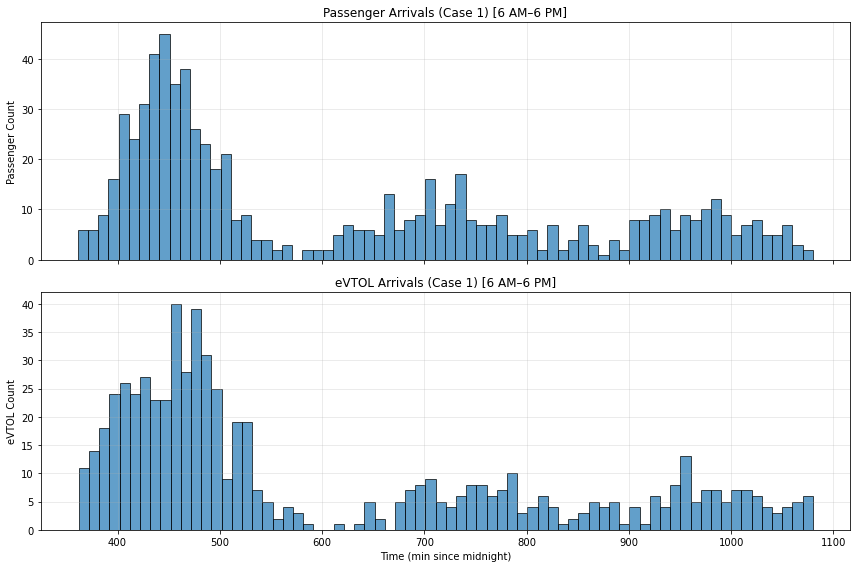

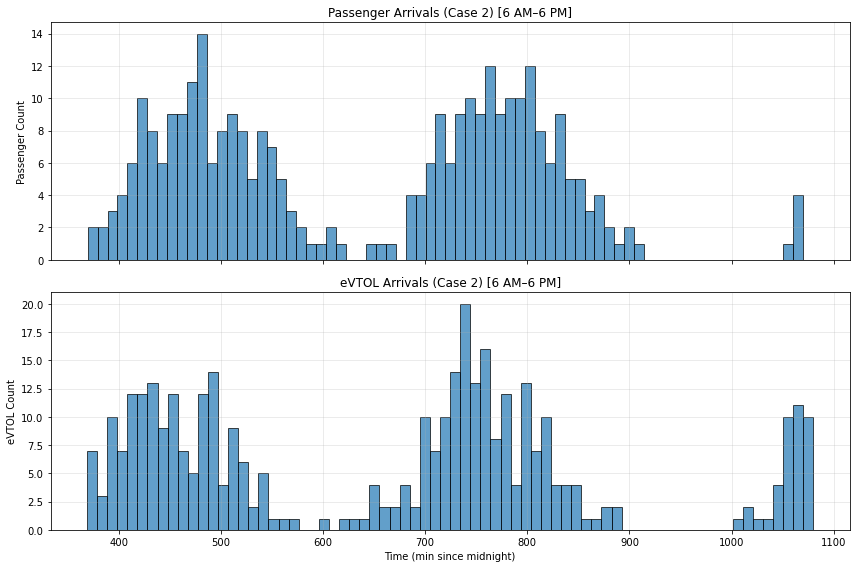


CASE 1: Passenger Distribution (Dallas CBD Hub)
DFW Airport                                178 passengers ( 24.4%)
Fort Worth City Center                     159 passengers ( 21.8%)
Denton Municipal Airport                    48 passengers (  6.6%)
Dallas Executive Airport (RBD)              69 passengers (  9.5%)
McKinney National Airport                   63 passengers (  8.6%)
Arlington Municipal Airport                 57 passengers (  7.8%)
Dallas Love Field Airport                   54 passengers (  7.4%)
Fort Worth Meacham International Airport    46 passengers (  6.3%)
Mesquite Metro Airport                      56 passengers (  7.7%)

CASE 2: Passenger Distribution (DFW Airport Hub)
Arlington Municipal Airport                 29 passengers (  9.2%)
Dallas CBD                                  74 passengers ( 23.6%)
Fort Worth City Center                      63 passengers ( 20.1%)
Denton Municipal Airport                    24 passengers (  7.6%)
Dallas Executive Airport (RBD)

In [ ]:
# ============================================================
# 🧭 Main Execution
# ============================================================
if __name__ == "__main__":
    """
    Entry point for simulation stage.
    Runs both Case 1 (Dallas CBD) and Case 2 (DFW Airport) with
    their respective passenger assignment rules.
    """

    # ------------------------------------------------------------
    # 🗺 Generate Vertiport Scenarios
    # ------------------------------------------------------------
    print("\n==========================")
    print("CASE 1: Dallas CBD Hub")
    print("==========================")
    m1 = run_scenario('Dallas CBD', 1)
    DESTINATION_DATA_CBD = {}
    hub_coord = vertiports['Dallas CBD']
    for name, coord in vertiports.items():
        if name != 'Dallas CBD':
            dist = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
            DESTINATION_DATA_CBD[name] = {'distance': dist, 'fare': round(20 + 3 * dist, 2)}

    print("\n==========================")
    print("CASE 2: DFW Airport Hub")
    print("==========================")
    m2 = run_scenario('DFW Airport', 2)
    DESTINATION_DATA_DFW = {}
    hub_coord = vertiports['DFW Airport']
    for name, coord in vertiports.items():
        if name != 'DFW Airport':
            dist = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
            DESTINATION_DATA_DFW[name] = {'distance': dist, 'fare': round(20 + 3 * dist, 2)}

    # ------------------------------------------------------------
    # 🚀 Run Simulation for Both Cases
    # ------------------------------------------------------------
    results_case1 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_CBD,
        assignment_case=1,
        plot=True
    )

    results_case2 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_DFW,
        assignment_case=2,
        plot=True
    )

    # ------------------------------------------------------------
    # 📊 Compare and Summarize Passenger Distribution
    # ------------------------------------------------------------
    from collections import Counter

    def print_distribution(results, title):
        print("\n" + "=" * 70)
        print(title)
        print("=" * 70)
        dest_count = Counter(results["destinations"].values())
        total = len(results["destinations"])
        for dest, count in dest_count.items():
            pct = (count / total) * 100
            print(f"{dest:<40} {count:5d} passengers ({pct:5.1f}%)")
        print("=" * 70)

    print_distribution(results_case1, "CASE 1: Passenger Distribution (Dallas CBD Hub)")
    print_distribution(results_case2, "CASE 2: Passenger Distribution (DFW Airport Hub)")

    # ------------------------------------------------------------
    # 🧩 Build PMFs for Each Case
    # ------------------------------------------------------------
    pmfs_case1, dests_case1 = build_bin_destination_pmfs(
        results_case1["passenger_arrivals"],
        results_case1["destinations"],
        results_case1["assignment_shares"]
    )

    pmfs_case2, dests_case2 = build_bin_destination_pmfs(
        results_case2["passenger_arrivals"],
        results_case2["destinations"],
        results_case2["assignment_shares"]
    )

    print("\nPMFs built for both cases successfully.")



## Joint Demand Scenario Generation with NHPP

In [ ]:
# ============================================================
# 🌐 Joint Demand Scenario Generator (NHPP + Bin PMFs, 6 AM–6 PM)
# ============================================================
def generate_joint_demand_scenarios(passenger_arrivals,
                                    evtol_arrivals,
                                    destination_data,
                                    bin_pmfs,
                                    n_scenarios=N_SCENARIOS,
                                    horizon_minutes=HORIZON_MINUTES,
                                    bin_size=BIN_SIZE,
                                    assignment_case=1,
                                    plot=True):
    """
    Generate multiple joint demand scenarios for passenger arrivals,
    eVTOL availability, and destination distributions using a 
    Nonhomogeneous Poisson Process (NHPP) framework.
    Supports 12-hour (6 AM–6 PM) horizon and assignment-specific labeling.
    """

    # ------------------------------------------------------------
    # 1. Define Time Discretization
    # ------------------------------------------------------------
    start_min, end_min = HORIZON_START, HORIZON_END
    l_periods = (end_min - start_min) // bin_size
    bin_edges = np.linspace(start_min, end_min, l_periods + 1)
    time_periods = np.arange(1, l_periods + 1)

    # ------------------------------------------------------------
    # 2. Build Baseline Histograms and Smooth Arrival Rates
    # ------------------------------------------------------------
    passenger_hist, _ = np.histogram(passenger_arrivals, bins=bin_edges)
    evtol_hist, _ = np.histogram(evtol_arrivals, bins=bin_edges)

    # Smooth baseline rates
    f_a = gaussian_filter1d(passenger_hist.astype(float), sigma=2)
    f_e = gaussian_filter1d(evtol_hist.astype(float), sigma=2)

    residuals_a = passenger_hist - f_a
    residuals_e = evtol_hist - f_e
    sigma_epsilon_sq = min(np.var(residuals_a), np.var(residuals_e))

    # ------------------------------------------------------------
    # 3. Generate Multiple NHPP-Based Scenarios
    # ------------------------------------------------------------
    scenarios = []
    for scenario_id in range(n_scenarios):
        epsilon_t = np.random.normal(0, np.sqrt(sigma_epsilon_sq), l_periods)

        lambda_a_omega = np.maximum(f_a + epsilon_t, 0)
        lambda_e_omega = np.maximum(f_e + epsilon_t, 0)

        a_t_omega = np.random.poisson(lambda_a_omega)
        e_t_omega = np.random.poisson(lambda_e_omega)

        # ---- Destination Sampling per Passenger Bin ----
        passenger_destinations, passenger_fares = {}, {}
        pid = 0
        for t in range(l_periods):
            n = int(a_t_omega[t])
            if n <= 0:
                continue

            pmf = bin_pmfs[t]
            dnames = list(pmf.keys())
            probs = np.array([pmf[d] for d in dnames], dtype=float)
            probs /= probs.sum() if probs.sum() > 0 else 1.0

            choices = np.random.choice(dnames, size=n, p=probs)
            for dname in choices:
                passenger_destinations[pid] = dname
                passenger_fares[pid] = destination_data[dname]["fare"]
                pid += 1

        dest_counts = Counter(passenger_destinations.values())

        scenarios.append({
            "id": scenario_id,
            "case": assignment_case,
            "a_t": a_t_omega,
            "e_t": e_t_omega,
            "total_passengers": int(np.sum(a_t_omega)),
            "total_evtols": int(np.sum(e_t_omega)),
            "destination_counts": dict(dest_counts),
            "passenger_destinations": passenger_destinations,
            "passenger_fares": passenger_fares
        })

    # ------------------------------------------------------------
    # 4. Optional Visualization of Smoothed Baseline Rates
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(time_periods, f_a, "o-", label="Passenger Baseline Rate")
        plt.plot(time_periods, f_e, "s-", label="eVTOL Baseline Rate")
        plt.title(
            f"Smoothed Arrival Rates (6 AM–6 PM) — Case {assignment_case}"
        )
        plt.xlabel("Time Period (10-min bins)")
        plt.ylabel("Expected Arrivals per Bin")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return scenarios



=== Running Case 1: Dallas CBD (Morning Peak) ===

=== Running Case 2: DFW Airport (Evening Peak) ===

=== Generating NHPP Scenarios: Case 1 (Dallas CBD) ===


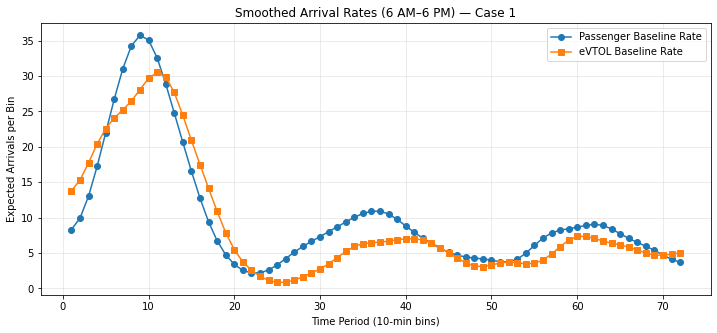


=== Generating NHPP Scenarios: Case 2 (DFW Airport) ===


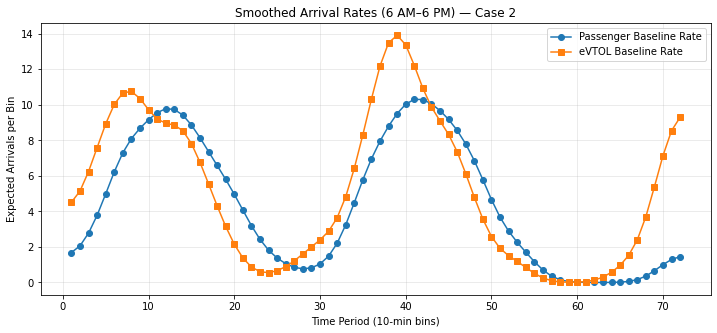


CASE 1 → Dallas CBD (Morning Peak) – Summary of 30 Scenarios (6 AM–6 PM)
Average passengers/scenario:   732.23
Average eVTOLs/scenario:       653.90
Destination Breakdown – Scenario 0:
  Fort Worth City Center                     165 passengers ( 23.8%)
  DFW Airport                                188 passengers ( 27.2%)
  Arlington Municipal Airport                 60 passengers (  8.7%)
  Mesquite Metro Airport                      36 passengers (  5.2%)
  Denton Municipal Airport                    45 passengers (  6.5%)
  Dallas Executive Airport (RBD)              46 passengers (  6.6%)
  McKinney National Airport                   60 passengers (  8.7%)
  Dallas Love Field Airport                   50 passengers (  7.2%)
  Fort Worth Meacham International Airport    42 passengers (  6.1%)

CASE 2 → DFW Airport (Evening Peak) – Summary of 30 Scenarios (6 AM–6 PM)
Average passengers/scenario:   321.53
Average eVTOLs/scenario:       373.50
Destination Breakdown – Scenario 0:
  Fort

In [ ]:
# ============================================================
# 🧭 Main Execution – Dual Hub Scenario Generation (6 AM–6 PM)
# ============================================================
if __name__ == "__main__":
    """
    Main pipeline for generating stochastic passenger and eVTOL demand scenarios.
    Integrates:
      (1) Baseline simulation per case (Dallas CBD & DFW Airport)
      (2) Per-bin destination PMF construction
      (3) NHPP-based joint scenario generation
      (4) Comparative summary and diagnostics
    """


    # ------------------------------------------------------------
    # 1. Run baseline simulations for both cases
    # ------------------------------------------------------------
    print("\n=== Running Case 1: Dallas CBD (Morning Peak) ===")
    res_case1 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_CBD,
        assignment_case=1,
        plot=False
    )

    print("\n=== Running Case 2: DFW Airport (Evening Peak) ===")
    res_case2 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_DFW,
        assignment_case=2,
        plot=False
    )

    # ------------------------------------------------------------
    # 2. Build per-bin destination PMFs (assignment-aware)
    # ------------------------------------------------------------
    pmfs_case1, _ = build_bin_destination_pmfs(
        passenger_arrivals=res_case1["passenger_arrivals"],
        passenger_dest_names=res_case1["destinations"],
        assignment_shares=res_case1["assignment_shares"],
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    pmfs_case2, _ = build_bin_destination_pmfs(
        passenger_arrivals=res_case2["passenger_arrivals"],
        passenger_dest_names=res_case2["destinations"],
        assignment_shares=res_case2["assignment_shares"],
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    # ------------------------------------------------------------
    # 4. Generate NHPP-based stochastic demand scenarios
    # ------------------------------------------------------------
    print("\n=== Generating NHPP Scenarios: Case 1 (Dallas CBD) ===")
    scenarios_case1 = generate_joint_demand_scenarios(
        passenger_arrivals=res_case1["passenger_arrivals"],
        evtol_arrivals=res_case1["evtol_arrivals"],
        destination_data=DESTINATION_DATA_CBD,
        bin_pmfs=pmfs_case1,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        assignment_case=1,
        plot=True
    )

    print("\n=== Generating NHPP Scenarios: Case 2 (DFW Airport) ===")
    scenarios_case2 = generate_joint_demand_scenarios(
        passenger_arrivals=res_case2["passenger_arrivals"],
        evtol_arrivals=res_case2["evtol_arrivals"],
        destination_data=DESTINATION_DATA_DFW,
        bin_pmfs=pmfs_case2,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        assignment_case=2,
        plot=True
    )

    # ------------------------------------------------------------
    # 5. Scenario Summary Comparison
    # ------------------------------------------------------------
    def summarize(label, scenarios):
        total_p = np.mean([s["total_passengers"] for s in scenarios])
        total_e = np.mean([s["total_evtols"] for s in scenarios])
        print("\n" + "=" * 90)
        print(f"{label} – Summary of {len(scenarios)} Scenarios (6 AM–6 PM)")
        print("=" * 90)
        print(f"Average passengers/scenario: {total_p:8.2f}")
        print(f"Average eVTOLs/scenario:     {total_e:8.2f}")
        print("=" * 90)

        s0 = scenarios[0]
        total0 = s0["total_passengers"] if s0["total_passengers"] > 0 else 1
        print("Destination Breakdown – Scenario 0:")
        for dest, cnt in s0["destination_counts"].items():
            pct = 100 * cnt / total0
            print(f"  {dest:<40} {cnt:5d} passengers ({pct:5.1f}%)")
        print("=" * 90)

    summarize("CASE 1 → Dallas CBD (Morning Peak)", scenarios_case1)
    summarize("CASE 2 → DFW Airport (Evening Peak)", scenarios_case2)

    # ------------------------------------------------------------
    # 6. Diagnostic Snapshot of Baseline Passengers
    # ------------------------------------------------------------
    print("\nDetailed Passenger Arrivals (Case 1 – first 15 shown):")
    for k in range(min(15, len(res_case1["passenger_arrivals"]))):
        dname = res_case1["destinations"][k]
        fare = res_case1["fares"][k]
        at = res_case1["passenger_arrivals"][k]
        print(f"  Passenger {k:3d}: {at:7.2f} min | {dname:<35} | Fare ${fare:6.2f}")
    print("=" * 90)


## Scenario Reduction via Backward Selection


In [ ]:
# ============================================================
# 🔻 Scenario Reduction with eVTOL Filtering (Backward Selection)
# ============================================================
def scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        assignment_case=None,
        plot=True):
    """
    Perform backward scenario reduction while ensuring all selected
    scenarios contain at least one eVTOL event. Compatible with
    6 AM–6 PM horizon and dual-case (Dallas CBD / DFW Airport) setup.
    """

    # ------------------------------------------------------------
    # 1. Filter Scenarios: Ensure at least one eVTOL present
    # ------------------------------------------------------------
    scenarios_with_evtols = [s for s in scenarios if s['total_evtols'] > 0]

    if len(scenarios_with_evtols) < target_size:
        scenarios_sorted = sorted(scenarios, key=lambda x: x['total_evtols'], reverse=True)
        scenarios_with_evtols = scenarios_sorted[:target_size]

    # ------------------------------------------------------------
    # 2. Initialize Probabilities & Feature Vectors
    # ------------------------------------------------------------
    n_original = len(scenarios_with_evtols)

    for scenario in scenarios_with_evtols:
        scenario['probability'] = 1.0 / n_original
        scenario['feature_vector'] = np.concatenate([
            scenario['a_t'],
            scenario['e_t']
        ])

    working_scenarios = scenarios_with_evtols.copy()

    # ------------------------------------------------------------
    # 3. Backward Reduction Loop
    # ------------------------------------------------------------
    while len(working_scenarios) > target_size:
        n_current = len(working_scenarios)
        distances = np.zeros((n_current, n_current))

        for i in range(n_current):
            for j in range(i + 1, n_current):
                dist = np.linalg.norm(
                    working_scenarios[i]['feature_vector'] -
                    working_scenarios[j]['feature_vector']
                )
                distances[i, j] = distances[j, i] = dist

        min_cost, remove_idx, nearest_neighbor = float('inf'), None, None
        for i in range(n_current):
            mask = np.ones(n_current, dtype=bool)
            mask[i] = False
            min_dist = np.min(distances[i, mask])
            cost = working_scenarios[i]['probability'] * min_dist

            if cost < min_cost:
                min_cost = cost
                remove_idx = i
                nearest_neighbor = np.argmin([
                    distances[i, j] if j != i else float('inf')
                    for j in range(n_current)
                ])

        working_scenarios[nearest_neighbor]['probability'] += \
            working_scenarios[remove_idx]['probability']
        _ = working_scenarios.pop(remove_idx)

    # ------------------------------------------------------------
    # 4. Normalize Final Probabilities
    # ------------------------------------------------------------
    total_prob = sum(s['probability'] for s in working_scenarios)
    for s in working_scenarios:
        s['probability'] /= total_prob

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        l_periods = len(working_scenarios[0]['a_t'])
        time_periods = np.arange(1, l_periods + 1)
        colors = ['#0072B2', '#E69F00', '#56B4E9', '#009E73', '#D55E00', '#CC79A7']

        case_label = f"Case {assignment_case}" if assignment_case else "Combined"
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(f"Reduced Scenario Set Analysis ({case_label}, 6 AM–6 PM)", 
                     fontsize=16, fontweight="bold")

        # (a) Passenger Arrivals
        for i, s in enumerate(working_scenarios):
            axes[0, 0].plot(time_periods, s['a_t'], 'o-', 
                            label=f"S{i+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 0].set_title("Passenger Arrivals per 10-min Bin")
        axes[0, 0].set_xlabel("Time (6 AM–6 PM)")
        axes[0, 0].set_ylabel("Passengers")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # (b) eVTOL Arrivals
        for i, s in enumerate(working_scenarios):
            axes[0, 1].plot(time_periods, s['e_t'], 's-', 
                            label=f"S{i+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 1].set_title("eVTOL Arrivals per 10-min Bin")
        axes[0, 1].set_xlabel("Time (6 AM–6 PM)")
        axes[0, 1].set_ylabel("eVTOL Count")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # (c) Scenario Probability Bars
        labels = [f"S{i+1}" for i in range(len(working_scenarios))]
        probs = [s['probability'] for s in working_scenarios]
        axes[1, 0].bar(labels, probs, color=colors[:len(labels)], alpha=0.8)
        axes[1, 0].set_title("Scenario Probabilities")
        axes[1, 0].set_ylabel("Probability")
        for idx, prob in enumerate(probs):
            axes[1, 0].text(idx, prob + 0.01, f"{prob:.2f}",
                            ha="center", fontweight="bold")
        axes[1, 0].grid(True, alpha=0.3)

        # (d) Original vs Reduced Comparison
        orig_p = [s['total_passengers'] for s in scenarios if s['total_evtols'] > 0]
        orig_e = [s['total_evtols'] for s in scenarios if s['total_evtols'] > 0]
        red_p = [s['total_passengers'] for s in working_scenarios]
        red_e = [s['total_evtols'] for s in working_scenarios]

        x = np.arange(2)
        w = 0.35
        axes[1, 1].bar(x - w/2, [np.mean(orig_p), np.mean(orig_e)], w,
                       label="Original Avg", alpha=0.6)
        axes[1, 1].bar(x + w/2, [np.mean(red_p), np.mean(red_e)], w,
                       label="Reduced Avg", alpha=0.8)
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(["Passengers", "eVTOLs"])
        axes[1, 1].set_title("Original vs Reduced Averages")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Reduced Scenario Set
    # ------------------------------------------------------------
    return working_scenarios



=== 🚖 Case 1: Dallas CBD (Morning Peak) ===

=== ✈️ Case 2: DFW Airport (Evening Peak) ===

=== 🧩 Generating Scenarios for Case 1 ===

=== 🧩 Generating Scenarios for Case 2 ===

=== 🔻 Reducing Scenarios – Case 1 (Dallas CBD) ===


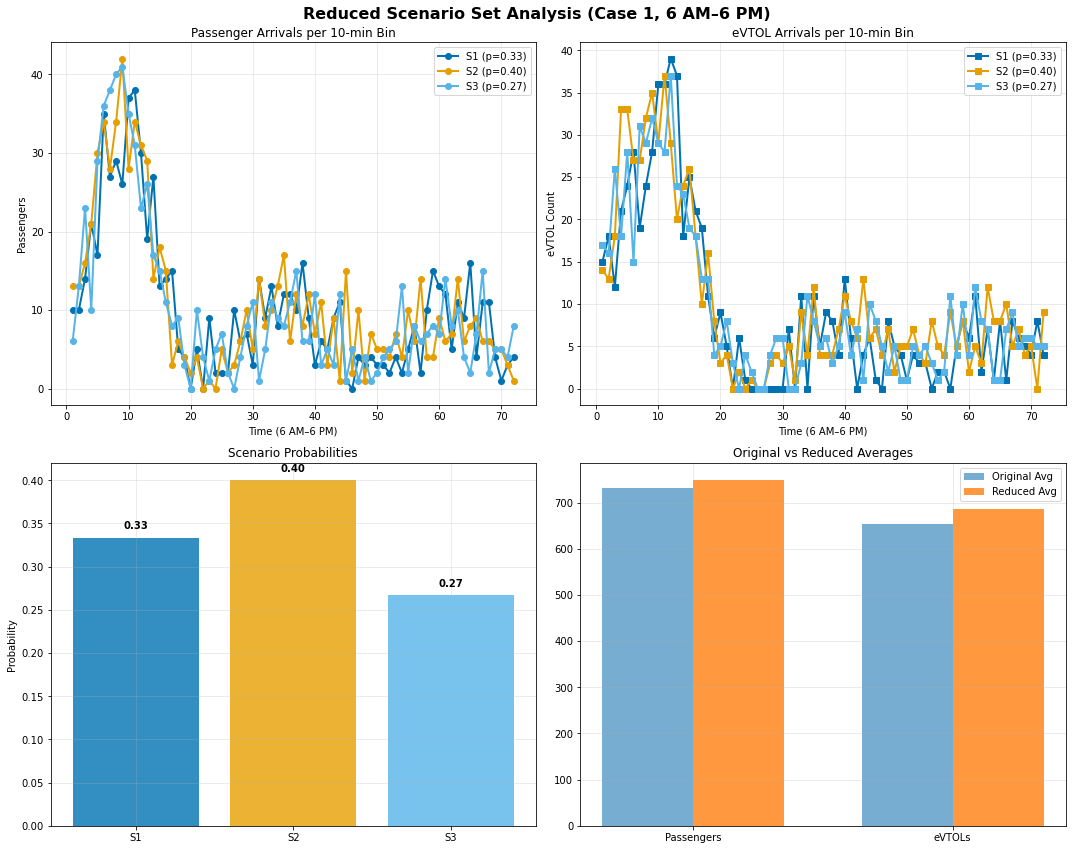


=== 🔻 Reducing Scenarios – Case 2 (DFW Airport) ===


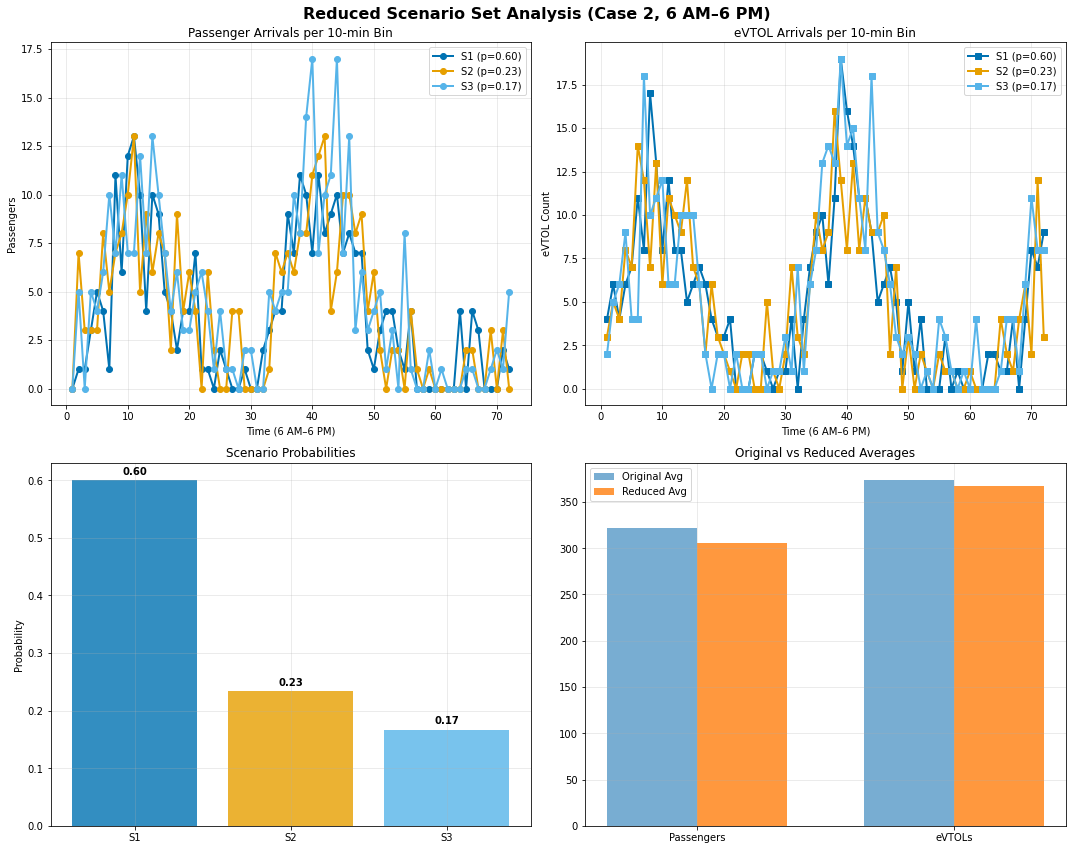


CASE 1 → Dallas CBD (Morning Peak) – Scenario Reduction Summary (6 AM–6 PM)
Initial Scenarios: 30
Reduced to:        3

Final Scenario Probabilities:
  Scenario 2   → p = 0.333
  Scenario 22  → p = 0.400
  Scenario 27  → p = 0.267

Average Passengers (Reduced): 748.67
Average eVTOLs (Reduced):   685.33

CASE 2 → DFW Airport (Evening Peak) – Scenario Reduction Summary (6 AM–6 PM)
Initial Scenarios: 30
Reduced to:        3

Final Scenario Probabilities:
  Scenario 6   → p = 0.600
  Scenario 18  → p = 0.233
  Scenario 23  → p = 0.167

Average Passengers (Reduced): 305.33
Average eVTOLs (Reduced):   367.67


In [ ]:
# ============================================================
# 🧭 Main Execution – Dual-Case Scenario Reduction Pipeline (6 AM–6 PM)
# ============================================================
if __name__ == "__main__":
    """
    Full pipeline for stochastic eVTOL scenario generation and reduction.

    Workflow:
      1. Baseline Simulation per Hub Case
      2. Joint Passenger–eVTOL Scenario Generation (NHPP-based)
      3. Backward Scenario Reduction with eVTOL Filtering
      4. Summary Reporting & Diagnostics
    """

    # ------------------------------------------------------------
    # 1️⃣ Baseline Simulation for Both Cases
    # ------------------------------------------------------------

    print("\n=== 🚖 Case 1: Dallas CBD (Morning Peak) ===")
    res_case1 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_CBD,
        assignment_case=1,
        plot=False
    )

    print("\n=== ✈️ Case 2: DFW Airport (Evening Peak) ===")
    res_case2 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_DFW,
        assignment_case=2,
        plot=False
    )

    # ------------------------------------------------------------
    # 2️⃣ Build Per-Bin Destination PMFs
    # ------------------------------------------------------------
    pmfs_case1, _ = build_bin_destination_pmfs(
        passenger_arrivals=res_case1["passenger_arrivals"],
        passenger_dest_names=res_case1["destinations"],
        assignment_shares=res_case1["assignment_shares"],
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    pmfs_case2, _ = build_bin_destination_pmfs(
        passenger_arrivals=res_case2["passenger_arrivals"],
        passenger_dest_names=res_case2["destinations"],
        assignment_shares=res_case2["assignment_shares"],
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    # ------------------------------------------------------------
    # 3️⃣ Generate NHPP-Based Scenarios
    # ------------------------------------------------------------
    print("\n=== 🧩 Generating Scenarios for Case 1 ===")
    scenarios_case1 = generate_joint_demand_scenarios(
        passenger_arrivals=res_case1["passenger_arrivals"],
        evtol_arrivals=res_case1["evtol_arrivals"],
        destination_data=DESTINATION_DATA_CBD,
        bin_pmfs=pmfs_case1,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        assignment_case=1,
        plot=False
    )

    print("\n=== 🧩 Generating Scenarios for Case 2 ===")
    scenarios_case2 = generate_joint_demand_scenarios(
        passenger_arrivals=res_case2["passenger_arrivals"],
        evtol_arrivals=res_case2["evtol_arrivals"],
        destination_data=DESTINATION_DATA_DFW,
        bin_pmfs=pmfs_case2,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        assignment_case=2,
        plot=False
    )

    # ------------------------------------------------------------
    # 4️⃣ Apply Backward Scenario Reduction (eVTOL Filter)
    # ------------------------------------------------------------
    print("\n=== 🔻 Reducing Scenarios – Case 1 (Dallas CBD) ===")
    reduced_case1 = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios_case1,
        target_size=TARGET_SCENARIOS,
        assignment_case=1,
        plot=True
    )

    print("\n=== 🔻 Reducing Scenarios – Case 2 (DFW Airport) ===")
    reduced_case2 = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios_case2,
        target_size=TARGET_SCENARIOS,
        assignment_case=2,
        plot=True
    )

    # ------------------------------------------------------------
    # 5️⃣ Summary Reports per Case
    # ------------------------------------------------------------
    def report_summary(label, all_scenarios, reduced):
        print("\n" + "=" * 90)
        print(f"{label} – Scenario Reduction Summary (6 AM–6 PM)")
        print("=" * 90)
        print(f"Initial Scenarios: {len(all_scenarios)}")
        print(f"Reduced to:        {len(reduced)}\n")

        print("Final Scenario Probabilities:")
        for s in reduced:
            print(f"  Scenario {s['id']+1:<3} → p = {s['probability']:.3f}")

        avg_pass = np.mean([s['total_passengers'] for s in reduced])
        avg_evtol = np.mean([s['total_evtols'] for s in reduced])

        print(f"\nAverage Passengers (Reduced): {avg_pass:.2f}")
        print(f"Average eVTOLs (Reduced):   {avg_evtol:.2f}")
        print("=" * 90)

    report_summary("CASE 1 → Dallas CBD (Morning Peak)", scenarios_case1, reduced_case1)
    report_summary("CASE 2 → DFW Airport (Evening Peak)", scenarios_case2, reduced_case2)


## Conditional Sampling of State of Charge (SoC)

In [ ]:
# ============================================================
# 🔋 Conditional SoC Sampling per eVTOL (Case-Aware, 6 AM–6 PM)
# ============================================================

def conditional_soc_sampling_per_evtol(
        reduced_scenarios,
        assignment_case=None,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=False):
    """
    Conditional SoC sampling for each eVTOL, case-aware (Dallas CBD or DFW Airport).

    Case 1 → Dallas CBD (Morning Peak): higher load earlier → lower SoC early
    Case 2 → DFW Airport (Evening Peak): higher load later → lower SoC later
    """

    case_label = {
        1: "Case 1 – Dallas CBD (Morning Peak)",
        2: "Case 2 – DFW Airport (Evening Peak)"
    }.get(assignment_case, "Unknown Case")

    # ------------------------------------------------------------
    # 1. Iterate through Reduced Scenarios
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        a_t_omega = np.array(scenario['a_t'], dtype=float)
        e_t_omega = np.array(scenario['e_t'], dtype=float)

        # ------------------------------------------------------------
        # 2. Compute Load Ratios per Period (ρ_t_ω)
        # ------------------------------------------------------------
        rho_t_omega = np.divide(
            a_t_omega,
            np.maximum(e_t_omega, 1e-3),  # avoid division by zero
        )

        # smooth small gaps where eVTOL=0 using rolling interpolation
        for t in range(1, len(rho_t_omega)):
            if e_t_omega[t] == 0:
                rho_t_omega[t] = rho_t_omega[t-1]

        evtol_socs = {}
        evtol_arrival_periods = {}
        evtol_count = 0

        # ------------------------------------------------------------
        # 3. Adjust parameters by case
        # ------------------------------------------------------------
        if assignment_case == 1:   # Morning hub (Dallas CBD)
            s_base_adj = s_base + 2        # slightly higher base (early ops)
            k_adj = k                      # default slope
        elif assignment_case == 2: # Evening hub (DFW Airport)
            s_base_adj = s_base - 3        # slightly lower baseline (evening fatigue)
            k_adj = k * 1.1                # slightly steeper decline
        else:
            s_base_adj, k_adj = s_base, k

        # ------------------------------------------------------------
        # 4. Sample SoC for Each eVTOL
        # ------------------------------------------------------------
        for t in range(len(e_t_omega)):
            n_evtols = int(e_t_omega[t])
            if n_evtols <= 0:
                continue

            load_ratio = rho_t_omega[t]
            mu_s = s_base_adj - k_adj * load_ratio
            sigma_s = sigma_base + sigma_scale * load_ratio

            mu_s = np.clip(mu_s, 25, 55)
            sigma_s = np.clip(sigma_s, 2, 8)

            # Sample SoC values for all eVTOLs arriving at this period
            for _ in range(n_evtols):
                evtol_id = evtol_count
                evtol_arrival_periods[evtol_id] = t + 1
                # Re-sample until valid SoC is drawn
                soc_sample = None
                while soc_sample is None or not (20 <= soc_sample <= 60):
                    soc_sample = np.random.normal(mu_s, sigma_s)
                evtol_socs[evtol_id] = soc_sample
                evtol_count += 1

        # ------------------------------------------------------------
        # 5. Store Updated Scenario Data
        # ------------------------------------------------------------
        scenario['rho_t_omega'] = rho_t_omega
        scenario['evtol_socs'] = evtol_socs
        scenario['evtol_arrival_periods'] = evtol_arrival_periods
        scenario['total_evtols_count'] = evtol_count
        scenario['avg_load_ratio'] = np.mean(rho_t_omega)
        scenario['assignment_case'] = assignment_case

    # ------------------------------------------------------------
    # 6. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 6))
        for s in reduced_scenarios:
            socs = list(s['evtol_socs'].values())
            plt.hist(socs, bins=8, alpha=0.6, edgecolor="black",
                     label=f"Scenario {s['id'] + 1}")
        plt.title(f"eVTOL State of Charge Distribution ({case_label}, 6 AM–6 PM)")
        plt.xlabel("State of Charge (%)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ------------------------------------------------------------
    # 7. Return Updated Scenario Set
    # ------------------------------------------------------------
    return reduced_scenarios



=== 🚖 Case 1: Dallas CBD (Morning Peak) ===

=== ✈️ Case 2: DFW Airport (Evening Peak) ===

=== 🧩 Generating Scenarios – Case 1 ===

=== 🧩 Generating Scenarios – Case 2 ===

=== 🔻 Reducing Scenarios – Case 1 ===

=== 🔻 Reducing Scenarios – Case 2 ===

=== 🔋 Sampling SoC – Case 1 (Morning Peak) ===


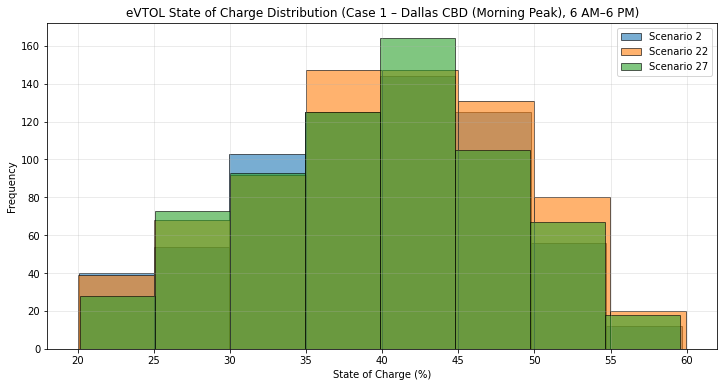


=== 🔋 Sampling SoC – Case 2 (Evening Peak) ===


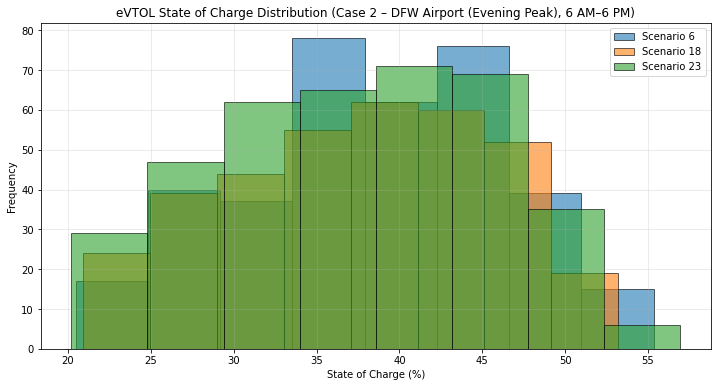


CASE 1 → Dallas CBD (Morning Peak) – Conditional SoC Sampling Summary (6 AM–6 PM)
Scenarios Evaluated: 3

Scenario  2:
  • Total eVTOLs:       659
  • Avg Load Ratio:     1.52
  • SoC Range:          20.1% – 59.7%
  • Mean SoC:           39.5%
  • Std Dev (SoC):      8.43

Scenario 22:
  • Total eVTOLs:       724
  • Avg Load Ratio:     1.45
  • SoC Range:          20.0% – 60.0%
  • Mean SoC:           40.1%
  • Std Dev (SoC):      8.68

Scenario 27:
  • Total eVTOLs:       673
  • Avg Load Ratio:     1.43
  • SoC Range:          20.1% – 59.6%
  • Mean SoC:           39.7%
  • Std Dev (SoC):      8.24


CASE 2 → DFW Airport (Evening Peak) – Conditional SoC Sampling Summary (6 AM–6 PM)
Scenarios Evaluated: 3

Scenario  6:
  • Total eVTOLs:       364
  • Avg Load Ratio:     0.82
  • SoC Range:          20.5% – 55.3%
  • Mean SoC:           38.3%
  • Std Dev (SoC):      7.77

Scenario 18:
  • Total eVTOLs:       355
  • Avg Load Ratio:     1.09
  • SoC Range:          20.9% – 53.2%
  • M

In [ ]:
# ============================================================
# 🧭 Main Execution – Conditional SoC Sampling per eVTOL (Case-Aware)
# ============================================================
if __name__ == "__main__":
    """
    Full pipeline for end-to-end stochastic eVTOL analysis:
      1. Baseline Simulation (per case)
      2. Joint Passenger–eVTOL Scenario Generation (NHPP-based)
      3. Backward Scenario Reduction with eVTOL Filtering
      4. Conditional SoC Sampling per eVTOL (Case-aware)
      5. Summary Diagnostics and Reporting
    """

    # ------------------------------------------------------------
    # 1️⃣ Baseline Simulation for Both Cases (6 AM – 6 PM)
    # ------------------------------------------------------------


    print("\n=== 🚖 Case 1: Dallas CBD (Morning Peak) ===")
    res_case1 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_CBD,
        assignment_case=1,
        plot=False
    )

    print("\n=== ✈️ Case 2: DFW Airport (Evening Peak) ===")
    res_case2 = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA_DFW,
        assignment_case=2,
        plot=False
    )

    # ------------------------------------------------------------
    # 2️⃣ Build Bin Destination PMFs per Case
    # ------------------------------------------------------------
    pmfs_case1, _ = build_bin_destination_pmfs(
        passenger_arrivals=res_case1["passenger_arrivals"],
        passenger_dest_names=res_case1["destinations"],
        assignment_shares=res_case1["assignment_shares"],
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    pmfs_case2, _ = build_bin_destination_pmfs(
        passenger_arrivals=res_case2["passenger_arrivals"],
        passenger_dest_names=res_case2["destinations"],
        assignment_shares=res_case2["assignment_shares"],
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    # ------------------------------------------------------------
    # 3️⃣ Generate NHPP-Based Scenarios (Per Case)
    # ------------------------------------------------------------
    print("\n=== 🧩 Generating Scenarios – Case 1 ===")
    scenarios_case1 = generate_joint_demand_scenarios(
        passenger_arrivals=res_case1["passenger_arrivals"],
        evtol_arrivals=res_case1["evtol_arrivals"],
        destination_data=DESTINATION_DATA_CBD,
        bin_pmfs=pmfs_case1,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        assignment_case=1,
        plot=False
    )

    print("\n=== 🧩 Generating Scenarios – Case 2 ===")
    scenarios_case2 = generate_joint_demand_scenarios(
        passenger_arrivals=res_case2["passenger_arrivals"],
        evtol_arrivals=res_case2["evtol_arrivals"],
        destination_data=DESTINATION_DATA_DFW,
        bin_pmfs=pmfs_case2,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        assignment_case=2,
        plot=False
    )

    # ------------------------------------------------------------
    # 4️⃣ Backward Scenario Reduction with eVTOL Filtering
    # ------------------------------------------------------------
    print("\n=== 🔻 Reducing Scenarios – Case 1 ===")
    reduced_case1 = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios_case1,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    print("\n=== 🔻 Reducing Scenarios – Case 2 ===")
    reduced_case2 = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios_case2,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ------------------------------------------------------------
    # 5️⃣ Conditional SoC Sampling per eVTOL (Case-Aware)
    # ------------------------------------------------------------
    print("\n=== 🔋 Sampling SoC – Case 1 (Morning Peak) ===")
    soc_case1 = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_case1,
        assignment_case=1,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=True
    )

    print("\n=== 🔋 Sampling SoC – Case 2 (Evening Peak) ===")
    soc_case2 = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_case2,
        assignment_case=2,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=True
    )

    # ------------------------------------------------------------
    # 6️⃣ Summary Diagnostics and Reporting
    # ------------------------------------------------------------
    def print_soc_summary(label, scenario_set):
        print("\n" + "=" * 90)
        print(f"{label} – Conditional SoC Sampling Summary (6 AM–6 PM)")
        print("=" * 90)
        print(f"Scenarios Evaluated: {len(scenario_set)}\n")
        for s in scenario_set:
            soc_vals = list(s['evtol_socs'].values())
            print(f"Scenario {s['id'] + 1:>2}:")
            print(f"  • Total eVTOLs:       {s['total_evtols_count']}")
            print(f"  • Avg Load Ratio:     {s['avg_load_ratio']:.2f}")
            print(f"  • SoC Range:          {min(soc_vals):.1f}% – {max(soc_vals):.1f}%")
            print(f"  • Mean SoC:           {np.mean(soc_vals):.1f}%")
            print(f"  • Std Dev (SoC):      {np.std(soc_vals):.2f}\n")
        print("=" * 90)

    print_soc_summary("CASE 1 → Dallas CBD (Morning Peak)", soc_case1)
    print_soc_summary("CASE 2 → DFW Airport (Evening Peak)", soc_case2)




## Input Data Preparation for Stochastic Optimization Model

In [ ]:
# ============================================================
# 🧮 Build Stochastic Optimization Model Input
# ============================================================

import random
import numpy as np
from collections import defaultdict


# ------------------------------------------------------------
# Function: Build Structured Input for Optimization Model
# ------------------------------------------------------------
def build_stochastic_model_input(
    reduced_scenarios,
    m_facilities=M_FACILITIES,
    l_periods=L_PERIODS,
    SoC_min=SOC_MIN,
    c=BATTERY_CAPACITY,
    qr=CHARGING_RATE,
    LoS=LOS,
    eVTOL_capacity=EVTOL_CAPACITY,
    destination_fares=None,
    destination_mapping=None,
    verbose=True
):
    """
    Construct structured stochastic input data for the eVTOL
    scheduling or charging optimization model.

    Parameters
    ----------
    reduced_scenarios : list[dict]
        Reduced scenarios from `conditional_soc_sampling_per_evtol()`.
    m_facilities : int
        Number of charging facilities available.
    l_periods : int
        Number of discrete time intervals (e.g., 24 for 4-hour horizon with 10-min bins).
    SoC_min : float
        Minimum required state of charge (%).
    c : float
        Battery capacity (kWh).
    qr : float
        Charging rate (kW).
    LoS : int
        Maximum allowed waiting time (periods).
    eVTOL_capacity : int
        Maximum passenger capacity per eVTOL.
    destination_fares : dict[int, float]
        Mapping {destination_id: fare_value}.
    destination_mapping : dict
        Dictionary containing both lookup maps:
        {
            "id_to_name": {1: "DFW Airport", ...},
            "name_to_id": {"DFW Airport": 1, ...}
        }
    verbose : bool, default=True
        Print detailed summary of the generated data.

    Returns
    -------
    stochastic_input : dict
        Model-ready structured dictionary with:
            - scenario-wise eVTOL & passenger data
            - global parameters and value ranges
    """

    # ------------------------------------------------------------
    # 0. Validation
    # ------------------------------------------------------------
    if destination_fares is None:
        raise ValueError("❌ Missing required parameter: destination_fares")

    if destination_mapping is None or 'id_to_name' not in destination_mapping:
        raise ValueError("❌ destination_mapping must contain {'id_to_name', 'name_to_id'}")

    destination_map = destination_mapping['id_to_name']
    name_to_number = destination_mapping['name_to_id']

    # ------------------------------------------------------------
    # 1. Initialize Master Structure
    # ------------------------------------------------------------
    stochastic_input = {
        "scenarios": {},
        "global_parameters": {
            "m_facilities": m_facilities,
            "l_periods": l_periods,
            "SoC_min": SoC_min,
            "c": c,
            "qr": qr,
            "LoS": LoS,
            "eVTOL_capacity": eVTOL_capacity,
            "destination_fares": destination_fares,
            "destination_mapping": destination_mapping
        }
    }

    # ------------------------------------------------------------
    # 2. Build Scenario-Specific Data
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        sid = scenario["id"]
        prob = scenario["probability"]
        n_evtols = scenario["total_evtols_count"]
        w_passengers = int(np.sum(scenario["a_t"]))

        scenario_data = {
            "probability": prob,
            "n_evtols": n_evtols,
            "w_passengers": w_passengers,
            "evtols": {},
            "agg_pass_demand": {}
        }

        # --------------------------------------------------------
        # 2.1 eVTOL Arrivals & Charging Parameters
        # --------------------------------------------------------
        evtol_arrivals = []
        for t, count in enumerate(scenario["e_t"]):
            for _ in range(int(count)):
                arrival_time = (t * BIN_SIZE) + random.uniform(0, BIN_SIZE)
                evtol_arrivals.append(arrival_time)
        evtol_arrivals.sort()

        # Retrieve SoC samples or fallback to uniform values
        soc_values = [
            scenario["evtol_socs"].get(eid, random.uniform(20, 60))
            for eid in range(n_evtols)
        ]

        for j, arrival_time in enumerate(evtol_arrivals):
            arrival_bin = int(arrival_time // BIN_SIZE) + 1
            soc = soc_values[j] if j < len(soc_values) else random.uniform(20, 60)

            # --- Charging Logic ---
            if soc < SoC_min:
                charge_needed = c * ((SoC_min - soc) / 100.0)
                hours_to_charge = charge_needed / qr
                periods_to_charge = hours_to_charge * (60 / BIN_SIZE)
                p_j = int(periods_to_charge) + 1
                finish_charging_period = min(arrival_bin + p_j, l_periods)

                total_cost, current_minute, remaining = 0, arrival_time, p_j
                while remaining > 0:
                    current_hour = (current_minute % 1440) / 60.0
                    energy_this_period = qr / (60 / BIN_SIZE)
                    total_cost += energy_this_period * energy_price_per_kWh(current_hour)
                    current_minute += BIN_SIZE
                    remaining -= 1
            else:
                p_j, finish_charging_period, total_cost = 0, arrival_bin, 0

            scenario_data["evtols"][j] = {
                "arrival_time": arrival_time,
                "arrival_bin": arrival_bin,
                "soc": soc,
                "charging_periods": p_j,
                "finish_charging_period": finish_charging_period,
                "charging_cost": total_cost,
            }

        # --------------------------------------------------------
        # 2.2 Aggregate Passenger Demand (Time × Destination)
        # --------------------------------------------------------
        agg_pass_demand = defaultdict(int)
        destinations = list(destination_fares.keys())

        for t, count in enumerate(scenario["a_t"]):
            for _ in range(int(count)):
                arrival_bin = int(t) + 1
                dest_num = random.choice(destinations)
                dest_name = destination_map.get(dest_num, f"Unknown-{dest_num}")
                agg_pass_demand[(arrival_bin, dest_num)] += 1

        # Ensure full coverage across time–destination pairs
        for t in range(1, l_periods + 1):
            for d in destination_fares.keys():
                agg_pass_demand.setdefault((t, d), 0)

        scenario_data["agg_pass_demand"] = dict(agg_pass_demand)
        stochastic_input["scenarios"][sid] = scenario_data

    # ------------------------------------------------------------
    # 3. Add Scenario Ranges
    # ------------------------------------------------------------
    all_evtols = [s["n_evtols"] for s in stochastic_input["scenarios"].values()]
    all_passengers = [s["w_passengers"] for s in stochastic_input["scenarios"].values()]

    stochastic_input["global_parameters"]["n_evtols_range"] = (min(all_evtols), max(all_evtols))
    stochastic_input["global_parameters"]["w_passengers_range"] = (min(all_passengers), max(all_passengers))

    # ------------------------------------------------------------
    # 4. Verbose Summary (Optional)
    # ------------------------------------------------------------
    if verbose:
        print("=" * 90)
        print("🧩 STOCHASTIC MODEL INPUT SUMMARY")
        print("=" * 90)
        print(f"Scenarios generated: {len(stochastic_input['scenarios'])}")
        print(f"Time window: 240–480 min ({l_periods} periods × {BIN_SIZE}-min bins)\n")

        for sid, data in stochastic_input["scenarios"].items():
            print(f"Scenario {sid:2d} (p={data['probability']:.3f}):")
            print(f"  - eVTOLs:       {data['n_evtols']}")
            print(f"  - Passengers:   {data['w_passengers']}")

            if data["evtols"]:
                print("  - eVTOL Details (first 10):")
                for eid, e in list(data["evtols"].items())[:10]:
                    print(f"      eVTOL {eid:3d}: Bin={e['arrival_bin']:3d}, "
                          f"Charge={e['charging_periods']:2d}p, "
                          f"SoC={e['soc']:5.1f}%, "
                          f"Cost=${e['charging_cost']:6.2f}")

            if data["agg_pass_demand"]:
                print("  - Passenger Demand (first 10 time–destination pairs):")
                for (t, d), count in list(data["agg_pass_demand"].items())[:10]:
                    dest_name = destination_map.get(d, f"Unknown-{d}")
                    print(f"      Time {t:2d} → Dest {d:2d} ({dest_name:<30}) : {count:3d}")

            print("-" * 80)

        print(f"\nRange of eVTOLs: {min(all_evtols)}–{max(all_evtols)}")
        print(f"Range of Passengers: {min(all_passengers)}–{max(all_passengers)}")
        print("=" * 90)

    return stochastic_input


In [ ]:
# ============================================================
# 🚀 MAIN EXECUTION PIPELINE (Full Workflow to Optimization)
# ============================================================

def main():
    """
    Full eVTOL stochastic pipeline:
        1️⃣ Simulate baseline passenger/eVTOL arrivals
        2️⃣ Build per-bin destination PMFs
        3️⃣ Generate stochastic demand scenarios
        4️⃣ Apply backward scenario reduction
        5️⃣ Add conditional SoC sampling per eVTOL
        6️⃣ Build compact stochastic model input
        7️⃣ (Optional) Solve aggregated stochastic optimization model
    """

    print("\n" + "=" * 100)
    print("🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION")
    print("=" * 100)

    # ============================================================
    # 1️⃣ Simulate Baseline Data
    # ============================================================
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False
    )
    print("✅ Baseline simulation completed successfully.")

    # ============================================================
    # 2️⃣ Build Destination PMFs (Per Time Bin)
    # ============================================================
    bin_pmfs, _ = build_bin_destination_pmfs(
        passenger_arrivals=results["passenger_arrivals"],
        passenger_dest_names=results["destinations"],
        start_min=240,
        end_min=480,
        bin_size=BIN_SIZE,
        alpha=1.0,
        focus_name="Fort Worth City Center",
        blend_weight=0.15,
        focus_share_target=0.60
    )
    print("✅ Per-bin destination PMFs constructed.")

    # ============================================================
    # 3️⃣ Generate Stochastic Scenarios (NHPP-based)
    # ============================================================
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ============================================================
    # 4️⃣ Scenario Reduction (Backward Selection)
    # ============================================================
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )
    print(f"✅ Scenario reduction complete — {len(reduced_scenarios)} key scenarios retained.")

    # ============================================================
    # 5️⃣ Conditional SoC Sampling per eVTOL
    # ============================================================
    reduced_scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # base SoC (%)
        k=12,               # degradation scaling factor
        sigma_base=3,       # baseline standard deviation
        sigma_scale=5,      # scaling for variance increase
        plot=False
    )
    print("✅ Conditional SoC sampling completed and appended to scenarios.")

    # ============================================================
    # 6️⃣ Build Destination Mapping (Number ↔ Name)
    # ============================================================
    destination_mapping = {
        "id_to_name": destination_map,
        "name_to_id": name_to_number
    }
    print("✅ Destination mapping structures created.")

    # ============================================================
    # 7️⃣ Build Stochastic Optimization Model Input
    # ============================================================
    print("\n📦 Building compact stochastic model input...")
    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=reduced_scenarios_with_soc,
        m_facilities=M_FACILITIES,
        l_periods=L_PERIODS,
        LoS=LOS,
        eVTOL_capacity=EVTOL_CAPACITY,
        destination_fares=numbered_fares,
        destination_mapping=destination_mapping,
        verbose=True
    )
    print("✅ Stochastic optimization model input built successfully.")


# ============================================================
# 🚀 EXECUTE FULL PIPELINE
# ============================================================
if __name__ == "__main__":
    main()



🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION
✅ Baseline simulation completed successfully.
✅ Per-bin destination PMFs constructed.
✅ Generated 30 stochastic demand scenarios.
✅ Scenario reduction complete — 3 key scenarios retained.
✅ Conditional SoC sampling completed and appended to scenarios.
✅ Destination mapping structures created.

📦 Building compact stochastic model input...
🧩 STOCHASTIC MODEL INPUT SUMMARY
Scenarios generated: 3
Time window: 240–480 min (24 periods × 10-min bins)

Scenario 15 (p=0.233):
  - eVTOLs:       274
  - Passengers:   296
  - eVTOL Details (first 10):
      eVTOL   0: Bin=  1, Charge= 3p, SoC= 32.9%, Cost=$  5.56
      eVTOL   1: Bin=  2, Charge= 3p, SoC= 33.4%, Cost=$  5.56
      eVTOL   2: Bin=  2, Charge= 2p, SoC= 48.0%, Cost=$  3.70
      eVTOL   3: Bin=  2, Charge= 3p, SoC= 36.0%, Cost=$  5.56
      eVTOL   4: Bin=  2, Charge= 4p, SoC= 27.4%, Cost=$  7.41
      eVTOL   5: Bin=  2, Charge= 4p, SoC= 28.3%, Cost=$  7.41
     

## Stochastic Optimization Model Fourmulation

In [ ]:
# ============================================================
# ⚙️ STOCHASTIC eVTOL SCHEDULING MODEL (GUROBI)
# ============================================================

import gurobipy as grb


def build_and_solve_stochastic_model_aggregated(
    stochastic_input,
    M=1000,
    verbose=True,
    unserved_penalty_cost=10,
):
    """
    Build and solve a **stochastic aggregated eVTOL scheduling model** using Gurobi.

    The model optimizes eVTOL charging assignments, passenger service allocation,
    and revenue–cost tradeoffs across multiple stochastic demand scenarios.

    Steps:
        1. Extract global data and indices
        2. Define decision variables (charging, assignment, service)
        3. Add logical and operational constraints
        4. Define revenue, charging, and penalty components
        5. Maximize expected profit
        6. Solve and report results

    Parameters
    ----------
    stochastic_input : dict
        Structured data from `build_stochastic_model_input()`.
    M : float, default=1000
        Big-M constant for logical linking constraints.
    verbose : bool, default=True
        Toggle solver output.
    Returns
    -------
    model : gurobipy.Model
        The optimized Gurobi model.
    results : dict
        Summary of optimization outcomes.
    """

    # =====================================================
    # 1️⃣ Extract Global Parameters and Sets
    # =====================================================
    global_params = stochastic_input["global_parameters"]
    m_facilities = global_params["m_facilities"]
    l_periods = global_params["l_periods"]
    eVTOL_capacity = global_params["eVTOL_capacity"]
    LoS = global_params["LoS"]
    destination_fares = global_params["destination_fares"]

    I = list(range(m_facilities))        # Facilities
    Time = list(range(1, l_periods + 1)) # Time bins
    S = list(stochastic_input["scenarios"].keys())  # Scenarios
    D = list(destination_fares.keys())   # Destinations

    # =====================================================
    # 2️⃣ Initialize Model
    # =====================================================
    model = grb.Model("Stochastic_eVTOL_Scheduling")
    if not verbose:
        model.Params.OutputFlag = 0
    model.Params.MIPGap = 0.05
    model.Params.TimeLimit = 300
    model.Params.DualReductions = 0

    # =====================================================
    # 3️⃣ Decision Variables
    # =====================================================
    x, C, F, z, pass_assigned, unserved_pass, Y, Tvar, use_evtol = {}, {}, {}, {}, {}, {}, {}, {}, {}

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        # eVTOL activation
        for j in J:
            use_evtol[j, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"use_{j}_{s}")

        # Charging assignment: x[i,j,t,s]
        for i in I:
            for j in J:
                for t in Time:
                    x[i, j, t, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"x_{i}_{j}_{t}_{s}")

        # Completion & takeoff times
        for j in J:
            C[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"C_{j}_{s}")
            F[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"F_{j}_{s}")

            for d in D:
                z[j, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"z_{j}_{d}_{s}")

            for t in Time:
                for d in D:
                    pass_assigned[j, t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"pass_{j}_{t}_{d}_{s}")
                    Y[j, t, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"Y_{j}_{t}_{d}_{s}")
                    Tvar[j, t, d, s] = model.addVar(lb=0, vtype=grb.GRB.CONTINUOUS, name=f"T_{j}_{t}_{d}_{s}")

        # Unserved passengers
        for t in Time:
            for d in D:
                unserved_pass[t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"unserved_{t}_{d}_{s}")

    model.update()

    # =====================================================
    # 4️⃣ Constraints (Scenario-specific)
    # =====================================================
    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        r = {j: scenario["evtols"][j]["arrival_bin"] for j in J}
        p = {j: scenario["evtols"][j]["charging_periods"] for j in J}
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}
        agg_pass_demand = scenario["agg_pass_demand"]

        # (1) Feasible charging assignment or deactivation
        for j in J:
            start, end = r[j], l_periods - p[j] + 1
            if start <= end:
                model.addConstr(grb.quicksum(x[i, j, t, s] for i in I for t in range(start, end + 1)) == use_evtol[j, s])
            else:
                model.addConstr(use_evtol[j, s] == 0)
                for i in I:
                    for t in Time:
                        model.addConstr(x[i, j, t, s] == 0)

        # (2) Facility capacity: one eVTOL per facility per period
        for i in I:
            for t in Time:
                model.addConstr(
                    grb.quicksum(x[i, j, u, s] for j in J for u in range(max(1, t - p[j] + 1), t + 1) if u >= r[j]) <= 1
                )

        # (3) Completion and takeoff
        for j in J:
            model.addConstr(C[j, s] == grb.quicksum((t + p[j] - 1) * x[i, j, t, s] for i in I for t in Time))
            model.addConstr(F[j, s] >= C[j, s])

        # (4) Destination and capacity linkage
        for j in J:
            model.addConstr(grb.quicksum(z[j, d, s] for d in D) <= use_evtol[j, s])
            model.addConstr(grb.quicksum(pass_assigned[j, t, d, s] for t in Time for d in D)
                            <= eVTOL_capacity * use_evtol[j, s])

        # (5) Link passengers → Y and Y → destination
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(pass_assigned[j, t, d, s] <= eVTOL_capacity * Y[j, t, d, s])
            for d in D:
                model.addConstr(grb.quicksum(Y[j, t, d, s] for t in Time) <= M * z[j, d, s])

        # (6) Demand balance
        for t in Time:
            for d in D:
                model.addConstr(
                    grb.quicksum(pass_assigned[j, t, d, s] for j in J) + unserved_pass[t, d, s] == agg_pass_demand[t, d]
                )

        # (7) Level of Service (tardiness bounds)
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(Tvar[j, t, d, s] >= F[j, s] - t - M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] <= LoS + M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] >= 0)

    # =====================================================
    # 5️⃣ Objective Function (Expected Profit)
    # =====================================================
    total_revenue, total_costs, total_penalty = 0, 0, 0

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        prob = scenario["probability"]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

        revenue = grb.quicksum(
            pass_assigned[j, t, d, s] * destination_fares[d]
            for j in J for t in Time for d in D
        )
        charge_cost = grb.quicksum(
            charging_cost[j] * grb.quicksum(x[i, j, t, s] for i in I for t in Time)
            for j in J
        )
        penalty = grb.quicksum(destination_fares[d] * unserved_pass[t, d, s] for t in Time for d in D)

        total_revenue += prob * revenue
        total_costs += prob * charge_cost
        total_penalty += prob * penalty

    model.setObjective(total_revenue - total_costs - total_penalty, grb.GRB.MAXIMIZE)

    # =====================================================
    # 6️⃣ Solve Model
    # =====================================================
    print("\n🚀 Solving stochastic scheduling model...")
    model.optimize()

    # =====================================================
    # 7️⃣ Status Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("✅ Optimal solution found.")
        print(f"   Objective Value: ${model.ObjVal:,.2f}")
    elif model.Status == grb.GRB.INFEASIBLE:
        print("❌ Model infeasible. Writing IIS to 'inf.ilp' ...")
        model.computeIIS()
        model.write("inf.ilp")
    elif model.Status == grb.GRB.UNBOUNDED:
        print("⚠️ Model unbounded.")
    elif model.Status == grb.GRB.INF_OR_UNBD:
        print("⚠️ Model infeasible or unbounded.")
    else:
        print(f"ℹ️ Optimization ended with status code {model.Status}.")

    # =====================================================
    # 8️⃣ Scenario-Wise Detailed Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("\n📊 DETAILED RESULTS PER SCENARIO\n")
        for s in S:
            scenario = stochastic_input["scenarios"][s]
            prob = scenario["probability"]
            J = list(scenario["evtols"].keys())
            charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

            served = sum(pass_assigned[j, t, d, s].X for j in J for t in Time for d in D)
            unserved = sum(unserved_pass[t, d, s].X for t in Time for d in D)
            revenue = sum(pass_assigned[j, t, d, s].X * destination_fares[d] for j in J for t in Time for d in D)
            lost = sum(unserved_pass[t, d, s].X * destination_fares[d] for t in Time for d in D)
            charge = sum(charging_cost[j] * sum(x[i, j, t, s].X for i in I for t in Time) for j in J)
            net = revenue - lost - charge

            print(f" Scenario {s} (p={prob:.2f}) → Served={served}, Unserved={unserved}, Net=${net:,.2f}")

    # =====================================================
    # 9️⃣ Return Results
    # =====================================================
    return model, {
        "status": model.Status,
        "objective": model.ObjVal if model.SolCount > 0 else None
    }


# Main Code

In [ ]:
# ============================================================
# 🚀 MAIN EXECUTION PIPELINE (Full Workflow to Optimization)
# ============================================================

def main():
    """
    Full eVTOL stochastic pipeline:
        1️⃣ Simulate baseline passenger/eVTOL arrivals
        2️⃣ Build per-bin destination PMFs
        3️⃣ Generate stochastic demand scenarios
        4️⃣ Apply backward scenario reduction
        5️⃣ Add conditional SoC sampling per eVTOL
        6️⃣ Build compact stochastic model input
        7️⃣ Solve aggregated stochastic optimization model
    """

    print("\n" + "=" * 100)
    print("🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION")
    print("=" * 100)

    # ============================================================
    # 1️⃣ Simulate Baseline Data
    # ============================================================
    results = simulate_evtol_and_passengers(
        seed=SEED,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        destination_data=DESTINATION_DATA,
        plot=False
    )
    print("✅ Baseline simulation completed successfully.")

    # ============================================================
    # 2️⃣ Build Destination PMFs (Per Time Bin)
    # ============================================================
    bin_pmfs, _ = build_bin_destination_pmfs(
        passenger_arrivals=results["passenger_arrivals"],
        passenger_dest_names=results["destinations"],
        start_min=240,
        end_min=480,
        bin_size=BIN_SIZE,
        alpha=1.0,
        focus_name="Fort Worth City Center",
        blend_weight=0.15,
        focus_share_target=0.60
    )
    print("✅ Per-bin destination PMFs constructed.")

    # ============================================================
    # 3️⃣ Generate Stochastic Scenarios (NHPP-based)
    # ============================================================
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=results["passenger_arrivals"],
        evtol_arrivals=results["evtol_arrivals"],
        destination_data=DESTINATION_DATA,
        bin_pmfs=bin_pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ============================================================
    # 4️⃣ Scenario Reduction (Backward Selection)
    # ============================================================
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )
    print(f"✅ Scenario reduction complete — {len(reduced_scenarios)} key scenarios retained.")

    # ============================================================
    # 5️⃣ Conditional SoC Sampling per eVTOL
    # ============================================================
    reduced_scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,          # Base SoC (%)
        k=12,               # SoC degradation factor
        sigma_base=3,       # Baseline std deviation
        sigma_scale=5,      # Variance scaling
        plot=False
    )
    print("✅ Conditional SoC sampling completed and appended to scenarios.")

    # ============================================================
    # 6️⃣ Build Destination Mapping (Number ↔ Name)
    # ============================================================
    destination_mapping = {
        "id_to_name": destination_map,
        "name_to_id": name_to_number
    }
    print("✅ Destination mapping structures created.")

    # ============================================================
    # 7️⃣ Build Stochastic Optimization Input
    # ============================================================
    print("\n📦 Building compact stochastic optimization model input...")
    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=reduced_scenarios_with_soc,
        m_facilities=M_FACILITIES,
        l_periods=L_PERIODS,
        LoS=LOS,
        eVTOL_capacity=EVTOL_CAPACITY,
        destination_fares=numbered_fares,
        destination_mapping=destination_mapping,
        verbose=False
    )
    print("✅ Stochastic model input built successfully.")

    # ============================================================
    # 8️⃣ Solve Aggregated Stochastic Optimization Model
    # ============================================================
    print("\n⚙️ Solving stochastic optimization model...")
    model, results = build_and_solve_stochastic_model_aggregated(stochastic_input)
    print("✅ Optimization completed successfully.")

    # ============================================================
    # 9️⃣ Summary Output
    # ============================================================
    print("\n" + "=" * 100)
    print("🎯 FULL STOCHASTIC PIPELINE COMPLETED SUCCESSFULLY ✅")
    if results["objective"]:
        print(f"Final Objective Value: ${results['objective']:,.2f}")
    print("=" * 100)


# ============================================================
# 🚀 EXECUTE FULL PIPELINE
# ============================================================
if __name__ == "__main__":
    main()



🛫 eVTOL STOCHASTIC WORKFLOW → REDUCTION → SoC SAMPLING → OPTIMIZATION
✅ Baseline simulation completed successfully.
✅ Per-bin destination PMFs constructed.
✅ Generated 30 stochastic demand scenarios.
✅ Scenario reduction complete — 3 key scenarios retained.
✅ Conditional SoC sampling completed and appended to scenarios.
✅ Destination mapping structures created.

📦 Building compact stochastic optimization model input...
✅ Stochastic model input built successfully.

⚙️ Solving stochastic optimization model...
Set parameter Username
Set parameter LicenseID to value 2681825
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 300
Set parameter DualReductions to value 0

🚀 Solving stochastic scheduling model...
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-6700HQ CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads



GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information